Using device: cuda
Loaded 106 images (Resolution: 100x100)
Camera poses ready (Task 3 complete).
Starting Training (This takes ~2-3 mins on GPU)...


100%|██████████| 1000/1000 [01:06<00:00, 15.01it/s]


Training Complete!
Rendering 360 degree video...


100%|██████████| 120/120 [00:04<00:00, 24.03it/s]


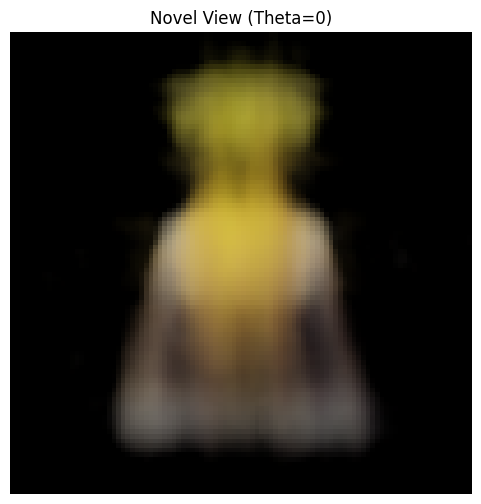

Video saved as 'tiny_nerf_result.mp4'. Download it to view the 3D rotation!


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import imageio

# ==========================================
# SETUP: CONFIGURATION & DATA (Task 1 & 2)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Download the standard "Tiny NeRF" dataset (Bulldozer/Lego)
if not os.path.exists('tiny_nerf_data.npz'):
    print("Downloading sample dataset...")
    !wget http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz

# Load Data (Images + Poses)
data = np.load('tiny_nerf_data.npz')
images = data['images']
poses = data['poses']
focal = data['focal']

# Convert to PyTorch tensors
H, W = images.shape[1:3]
images = torch.from_numpy(images).to(device)
poses = torch.from_numpy(poses).to(device)
focal = torch.from_numpy(focal).to(device)

print(f"Loaded {images.shape[0]} images (Resolution: {H}x{W})")
print("Camera poses ready (Task 3 complete).")

# ==========================================
# MODEL DEFINITION: TINY NeRF
# ==========================================
class TinyNeRF(nn.Module):
    def __init__(self, filter_size=128, encoding_size=6):
        super(TinyNeRF, self).__init__()
        # Input: 3D position (x,y,z) + Positional Encoding
        self.layer1 = nn.Linear(3 + 3 * 2 * encoding_size, filter_size)
        self.layer2 = nn.Linear(filter_size, filter_size)
        self.layer3 = nn.Linear(filter_size, 4) # Output: RGB (3) + Density (1)
        self.relu = nn.functional.relu
        self.encoding_size = encoding_size

    def positional_encoding(self, x):
        """Input: [N, 3] -> Output: [N, 3 + 3*2*encoding_size]"""
        encoded = [x]
        for i in range(self.encoding_size):
            encoded.append(torch.sin(2**i * x))
            encoded.append(torch.cos(2**i * x))
        return torch.cat(encoded, dim=-1)

    def forward(self, x):
        x = self.positional_encoding(x)
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

# ==========================================
# HELPER: VOLUMETRIC RENDERING
# ==========================================
def get_rays(H, W, focal, c2w):
    """Get ray origins and directions from a camera pose."""
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32).to(device),
                          torch.arange(H, dtype=torch.float32).to(device), indexing='xy')
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], -1)
    rays_d = torch.sum(dirs[..., None, :] * c2w[:3, :3], -1)
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

def render_rays(model, rays_o, rays_d, near=2.0, far=6.0, n_samples=64):
    """
    Volumetric rendering:
    1. Sample points along rays
    2. Query NeRF model for RGB & Density
    3. Accumulate samples into final pixel color
    """
    # 1. Sample points along the ray
    z_vals = torch.linspace(near, far, n_samples).to(device)
    # Shape: [H, W, n_samples, 3]
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    # 2. Run Network
    # Flatten to [Batch, 3] for the network
    flat_pts = pts.reshape(-1, 3)
    raw = model(flat_pts)
    raw = raw.reshape(H, W, n_samples, 4)

    # 3. Volume Rendering Equation
    # Sigma (Density) -> Alpha
    sigma = F.relu(raw[..., 3])
    rgb = torch.sigmoid(raw[..., :3])

    dists = torch.cat([z_vals[..., 1:] - z_vals[..., :-1],
                       torch.tensor([1e10], device=device).expand(z_vals[..., :1].shape)], -1)
    alpha = 1.0 - torch.exp(-sigma * dists)

    # Weights (Transmitance * Alpha)
    weights = alpha * torch.cumprod(1.0 - alpha + 1e-10, dim=-1)

    rgb_map = torch.sum(weights[..., None] * rgb, -2)
    return rgb_map

# ==========================================
# TASK 4: TRAINING LOOP
# ==========================================
model = TinyNeRF().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.MSELoss()

# We train on one image (Image 101) as test set, rest as train
test_img_idx = 101
target_img = images[test_img_idx]
test_pose = poses[test_img_idx]

print("Starting Training (This takes ~2-3 mins on GPU)...")
train_psnrs = []

for i in tqdm(range(1000)): # 1000 Iterations
    # Randomly select a target image from dataset
    img_idx = np.random.randint(images.shape[0])
    target = images[img_idx]
    pose = poses[img_idx]

    # Generate rays for this camera pose
    rays_o, rays_d = get_rays(H, W, focal, pose)

    # Run Model & Render
    rgb_predicted = render_rays(model, rays_o, rays_d)

    # Calculate Loss & Backprop
    loss = criterion(rgb_predicted, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % 100 == 0:
        psnr = -10. * torch.log10(loss)
        train_psnrs.append(psnr.item())

print("Training Complete!")

# ==========================================
# TASK 5 & 6: GENERATE NOVEL VIEWS & DISPLAY
# ==========================================
print("Rendering 360 degree video...")

# Create a circular camera path
trans_t = lambda t : torch.tensor([
    [1,0,0,0],
    [0,1,0,0],
    [0,0,1,t],
    [0,0,0,1],
], dtype=torch.float32).to(device)

rot_phi = lambda phi : torch.tensor([
    [1,0,0,0],
    [0,np.cos(phi),-np.sin(phi),0],
    [0,np.sin(phi), np.cos(phi),0],
    [0,0,0,1],
], dtype=torch.float32).to(device)

rot_theta = lambda th : torch.tensor([
    [np.cos(th),0,-np.sin(th),0],
    [0,1,0,0],
    [np.sin(th),0, np.cos(th),0],
    [0,0,0,1],
], dtype=torch.float32).to(device)

def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(phi/180.*np.pi) @ c2w
    c2w = rot_theta(theta/180.*np.pi) @ c2w
    c2w = torch.tensor([[-1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]], dtype=torch.float32).to(device) @ c2w
    return c2w

frames = []
with torch.no_grad():
    for th in tqdm(np.linspace(0., 360., 120, endpoint=False)):
        c2w = pose_spherical(th, -30.0, 4.0)
        rays_o, rays_d = get_rays(H, W, focal, c2w[:3, :4])
        rgb = render_rays(model, rays_o, rays_d)
        frames.append((255 * np.clip(rgb.cpu().numpy(), 0, 1)).astype(np.uint8))

# Save video
imageio.mimsave('tiny_nerf_result.mp4', frames, fps=30)

# Display one generated frame
plt.figure(figsize=(6,6))
plt.imshow(frames[0])
plt.title(f"Novel View (Theta=0)")
plt.axis('off')
plt.show()

print("Video saved as 'tiny_nerf_result.mp4'. Download it to view the 3D rotation!")